# Importations

In [ ]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import special_ortho_group

import sympy as sp

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import combinations, product

from IPython.display import display, Math

# Local importations
from moments.bloch import (generate_pauli_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_vector, compute_dm_from_bloch, compute_bloch_norms_from_vector)
from moments.quantum import generate_rand_dm, compute_is_valid_dm
from moments.ent_meas import compute_concurrence, compute_negativity

# Definitions

In [2]:
def compute_rand_SO_subset(subset_index_map):
    Q = {}
    for subset in subset_index_map.keys():
        Q[subset] = special_ortho_group.rvs(len(subset_index_map[subset]))
    return Q

def check_tensor_rot(Q):
    for subset in Q.keys():
        if len(subset) > 1:
            Q_tensor = np.array([1])
            for m in subset:
                Q_tensor = np.kron(Q_tensor, Q[(m,)])
            if np.allclose(Q[subset], Q_tensor):
                return False
    return True

In [ ]:
dn, N = 2, 2
dim = [dn]*N
d = int(np.prod(dim))

pauli_basis = generate_pauli_basis()

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

# Viability test

In [4]:
is_valid = False
j = 0

while not is_valid:
    j += 1
    
    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q = compute_rand_SO_subset(subset_index_map)
    if not check_tensor_rot(Q):
        print("Warning: Q_M is equal to the tensor product of Q_m for some M")
    
    r_rot = {subset: Q[subset] @ r[subset] for subset in subset_index_map.keys()}
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)


Sucess: True
Number of iterations: 2


# Local identity rotations

$$
Q_1 = Q_2 = \mathbb I_3
$$

In [5]:
is_valid = False
j = 0

while not is_valid:
    j += 1

    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q_12 = special_ortho_group.rvs(9)
    if np.allclose(Q_12, np.identity(9)):
        print("Warning: Q_12 is equal to the tensor product of Q_1 and Q_2 (i.e. the identity).")
    
    r_rot = r.copy()
    r_rot[(1, 2)] = Q_12 @ r_rot[(1, 2)]
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 8


In [6]:
R = compute_bloch_norms_from_vector(r)
R_rot = compute_bloch_norms_from_vector(r_rot)

bloch_diff = {subset: np.allclose(r[subset], r_rot[subset]) for subset in subset_index_map}
length_diff = {subset: np.allclose(R[subset], R_rot[subset]) for subset in subset_index_map}
DC = abs(compute_concurrence(rho) - compute_concurrence(rho_rot))
DN = abs(compute_negativity(rho = rho) - compute_negativity(rho = rho_rot))

print("One-body Bloch vectors are constant:", (bloch_diff[(1,)] and bloch_diff[(2,)]))
print("Two-body Bloch vector is constant:", bloch_diff[(1, 2)])
print("Density matrix is constant:", np.allclose(rho, rho_rot))
print("Bloch lengths are constant:", all(list(length_diff.values())))
print(f"Concurrences difference: {DC:.4f}")
print(f"Negativity difference: {DN:.4f}")

One-body Bloch vectors are constant: True
Two-body Bloch vector is constant: False
Density matrix is constant: False
Bloch lengths are constant: True
Concurrences difference: 0.0676
Negativity difference: 0.0259


# Exact rotations

In [ ]:
def iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True):
    if 0 in value_range:
        raise ValueError("value range must not include 0 (need exactly k nonzero entries)")
    
    arr = np.zeros(size, dtype=dtype)

    for idx_tuple in combinations(range(size), k):
        idx = np.fromiter(idx_tuple, dtype=np.intp, count=k)
        for values in product(value_range, repeat=k):
            arr[idx] = values
            yield arr.copy() if copy else arr
        arr[idx] = 0

In [8]:
a = 0.5
r = {(1,): a * np.array([0, 0, 1]), (2,): a * np.array([0, 0, 1]), (1, 2): np.array([0, 0, 0, 0, 0, 0, 0, 0, 1])}

rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
is_valid, _ = compute_is_valid_dm(rho)

C, N = compute_concurrence(rho = rho), compute_negativity(rho=rho)

print("Original state:\n")
print(rho)
print("\nIs a valid density matrix?", is_valid)
print("\nConcurrence:", C)
print("Negativity:", N)

Original state:

[[0.75+0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.25+0.j]]

Is a valid density matrix? True

Concurrence: 0.0
Negativity: 0.0


In [9]:
k = 3
results, concurrences, negativities = [], [], []

for j, r_12 in enumerate(iterate_k_nonzero_arrays(k, max_value = 3)):
    
    r_rot = r.copy()
    r_rot[(1, 2)] = r_12 / np.linalg.norm(r_12)
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)
    if is_valid:
        print(f'\n# {j}:\nr_12 = {r_12}.')
        C_rot, N_rot = compute_concurrence(rho=rho_rot), compute_negativity(rho=rho_rot)
        print(f"C = {C_rot:.4f}")
        print(f"N = {N_rot:.4f}")
        results.append(j)
        concurrences.append(C_rot)
        negativities.append(N_rot)


# 1026:
r_12 = [0. 1. 0. 1. 0. 0. 0. 0. 1.].
C = 0.3660
N = 0.1830

# 1027:
r_12 = [0. 1. 0. 1. 0. 0. 0. 0. 2.].
C = 0.3165
N = 0.1582

# 1028:
r_12 = [0. 1. 0. 1. 0. 0. 0. 0. 3.].
C = 0.2538
N = 0.1269

# 1030:
r_12 = [0. 1. 0. 2. 0. 0. 0. 0. 2.].
C = 0.3333
N = 0.1667

# 1036:
r_12 = [0. 2. 0. 1. 0. 0. 0. 0. 2.].
C = 0.3333
N = 0.1667

# 1039:
r_12 = [0. 2. 0. 2. 0. 0. 0. 0. 2.].
C = 0.3660
N = 0.1830

# 1040:
r_12 = [0. 2. 0. 2. 0. 0. 0. 0. 3.].
C = 0.3489
N = 0.1744

# 1043:
r_12 = [0. 2. 0. 3. 0. 0. 0. 0. 3.].
C = 0.3528
N = 0.1764

# 1049:
r_12 = [0. 3. 0. 2. 0. 0. 0. 0. 3.].
C = 0.3528
N = 0.1764

# 1052:
r_12 = [0. 3. 0. 3. 0. 0. 0. 0. 3.].
C = 0.3660
N = 0.1830


In [10]:
j_max = np.argmax(np.array(concurrences))
k_max = np.argmax(np.array(negativities))

print("Maximum concurrence")
print(f"# {results[j_max]}:")
print(f"C = {concurrences[j_max]:.4f}")
print(f"N = {negativities[k_max]:.4f}")

if j_max != k_max:
    print("\nMaximums do not coincide!")

Maximum concurrence
# 1052:
C = 0.3660
N = 0.1830

Maximums do not coincide!


# Symbolic counterexample

In [11]:
def get_principal_minors(matrix):
    n = matrix.shape[0]
    principal_minors = []
    
    for size in range(1, n + 1):
        for indices in combinations(range(n), size):
            # Extract the principal submatrix
            submatrix = matrix[indices, indices]
            det = sp.simplify(submatrix.det())
            principal_minors.append((indices, det))
    
    return principal_minors


## Symbolic positivity

In [12]:
# Define symbolic parameters
a, b, c = sp.symbols('a b c', real=True)

# Define Pauli matrices and identity
sigma0 = sp.eye(2)
sigma1 = sp.Matrix([[0, 1], [1, 0]])
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])

pauli = [sigma0, sigma1, sigma2, sigma3]

# Define vectors r1, r2, r12
r1 = [0, 0, 1]
r2 = [0, 0, 1]
r12 = sp.Matrix([[0, a, 0], [b, 0, 0], [0, 0, c]])

# Scalar prefactors
alpha, beta = sp.Rational(1, 2), sp.Rational(1, 2)

# Construct density matrix rho
rho = sp.eye(4)
for i in range(1, 4):
    rho += alpha * r1[i-1] * sp.kronecker_product(pauli[i], pauli[0])
    rho += beta * r2[i-1] * sp.kronecker_product(pauli[0], pauli[i])
    for j in range(1, 4):
        rho += r12[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[j])

# Simplify rho
rho = sp.simplify(sp.Rational(1, 4) * rho)

display(Math('\\rho = \\frac{1}{4} ' + sp.latex(4*rho)))

<IPython.core.display.Math object>

In [13]:
# Compute eigenvalues of rho
eigenvals = rho.eigenvals()
eig_list = []
for val, mult in eigenvals.items():
    for _ in range(mult):
        eig_list.append(val)
        display(Math(sp.latex(val)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Symbolic negativity

In [14]:
signs = [1, -1, 1]
# Construct density matrix rho
rho_pt = sp.eye(4)
for i in range(1, 4):
    rho_pt += signs[i-1] * alpha * r1[i-1] * sp.kronecker_product(pauli[i], pauli[0])
    rho_pt += beta * r2[i-1] * sp.kronecker_product(pauli[0], pauli[i])
    for j in range(1, 4):
            rho_pt += signs[i-1] * r12[i-1, j-1] * sp.kronecker_product(pauli[i], pauli[j])

# Simplify rho_pt
rho_pt = sp.simplify(sp.Rational(1, 4) * rho_pt)

display(Math('\\rho = \\frac{1}{4} ' + sp.latex(4*rho_pt)))

<IPython.core.display.Math object>

In [15]:
# Compute eigenvalues
eigenvals = rho_pt.eigenvals()
eig_list = []
for val, mult in eigenvals.items():
    for _ in range(mult):
        eig_list.append(val)
        display(Math(sp.latex(val)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Optimal entanglement in the family

In [16]:
def symbolic_negativity(a, b, c):
    lambda_1 = (1/4) *  (- a - b - c + 1)
    lambda_2 = (1/4) * (a + b - c + 1)
    lambda_3 = (1/4) * (- np.sqrt((a - b)**2 + 1) + c + 1)
    lambda_4 = (1/4) * (np.sqrt((a - b)**2 + 1) + c + 1)
    return 0.5 * (np.abs(lambda_1) + np.abs(lambda_2) + np.abs(lambda_3) + np.abs(lambda_4) - 1)

def is_admissible(x, y, z, tol=1e-10):
    constraint1 = np.abs(x**2 + y**2 + z**2 - 1) <= tol
    constraint2 = x - y - z >= -1
    constraint3 = y - x - z >= -1
    constraint4 = 2*z*(z + 1) >= 2*x*y + 1
    
    return constraint1 & constraint2 & constraint3 & constraint4

In [17]:
resolution = 1000

# Generate points on the sphere using spherical coordinates
theta = np.linspace(0, np.pi, resolution)
phi = np.linspace(0, 2*np.pi, resolution)
    
theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    
# Convert spherical to Cartesian
a = np.sin(theta_grid) * np.cos(phi_grid)
b = np.sin(theta_grid) * np.sin(phi_grid)
c = np.cos(theta_grid)
    
# Apply constraints 2, 3, and 4
mask = is_admissible(a, b, c)
    
# Create masked arrays
a_adm = np.ma.masked_where(~mask, a)
b_adm = np.ma.masked_where(~mask, b)
c_adm = np.ma.masked_where(~mask, c)

# Evaluate the negativity on the admissible domain
N_values = np.ma.masked_where(~mask, 2 * symbolic_negativity(a_adm, b_adm, c_adm))

/var/folders/19/03bx9f_s20j_s0p6swyfz0zc0000gr/T/ipykernel_3848/2160871500.py:4: RuntimeWarning: invalid value encountered in sqrt
  lambda_3 = (1/4) * (- np.sqrt((a - b)**2 + 1) + c + 1)
/var/folders/19/03bx9f_s20j_s0p6swyfz0zc0000gr/T/ipykernel_3848/2160871500.py:5: RuntimeWarning: invalid value encountered in sqrt
  lambda_4 = (1/4) * (np.sqrt((a - b)**2 + 1) + c + 1)


Number of admissible points: 39454
Function value range: 0.000000 to 0.366025


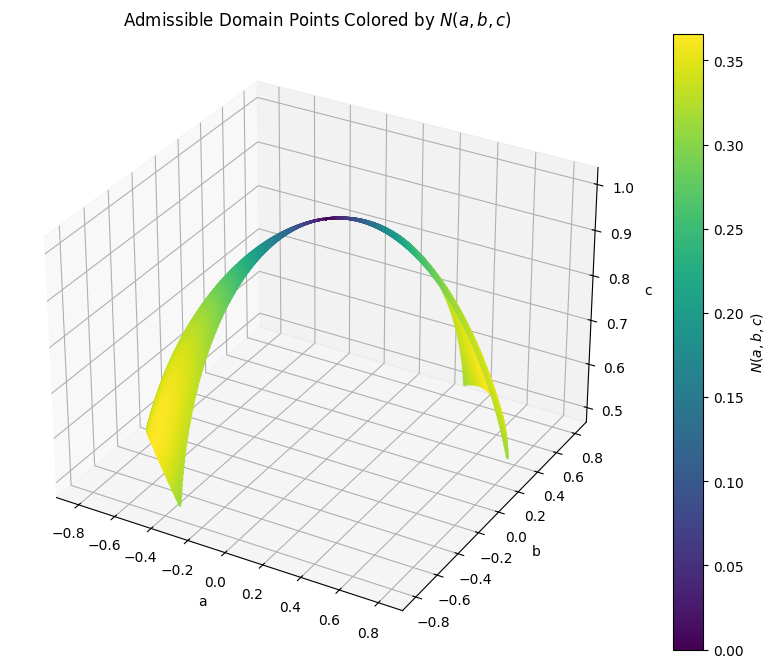

In [18]:
# Print information
n_points = np.sum(~N_values.mask)
print(f"Number of admissible points: {n_points}")
print(f"Function value range: {N_values.min():.6f} to {N_values.max():.6f}")

# Create 3D scatter plot of admissible points colored by function value
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
    
# Plot the admissible points
scatter = ax.scatter(a_adm.compressed(), b_adm.compressed(), c_adm.compressed(), c=N_values.compressed(), cmap='viridis', s=1)

ax.set(xlabel = 'a', ylabel = 'b', zlabel = 'c', title = r'Admissible Domain Points Colored by $N(a, b, c)$')
plt.colorbar(scatter, label = r'$N(a, b, c)$')

plt.show()

In [19]:
max_value = np.ma.max(N_values)
max_index = np.ma.where(N_values == max_value)

# Extract the coordinates
a_max = a_adm[max_index[0][0], max_index[1][0]]
b_max = b_adm[max_index[0][0], max_index[1][0]]
c_max = c_adm[max_index[0][0], max_index[1][0]]

print(f"Maximum negativity value: {max_value}")
print(f"Coordinates (a, b, c): ({a_max:.6f}, {b_max:.6f}, {c_max:.6f})")
print("1/sqrt(3) = 0.577")

Maximum negativity value: 0.36602502295188066
Coordinates (a, b, c): (0.577175, 0.578083, 0.576792)
1/sqrt(3) = 0.577
